# §8 — Analyze the Whole-Cell Model (10 prepared replicates)

1. **Aim:** Analyze the trajectories from the spatially homogeneous CME–ODE WCM of the minimal cell.
2. **Data:** Ten pre-run cell replicates (full cell cycle), read from the shared read-only bgvl folder `/projects/bgvl/SummerSchool_2026/CME/WCM/analysis/WCM_10Cells.pkl`.

> **Kernel:** select **`LM 2.5 (Python 3.7)`**. The figures reproduce those in the [WCM README](../README.md#6-analysis-and-discussion).

*This notebook was written for the NSF STC-QCB Summer School.*

### Set up Python Environment

In [1]:
# Import Standard Python Packages

import numpy as np
from Bio import SeqIO
import pandas as pd
from collections import Counter
import re
import importlib
import os
import sys
sys.path.append('../../analyze_scripts/')

In [2]:
# Import Custom Python modules

import WCM_analysis
import WCM_gene as gene
import WCM_diagnosis as diagnosis
import WCM_ptn as ptn
import WCM_ribo as ribo
import WCM_math as math
import custom_plot as plot

In [3]:
# Disable Latex rendering

import matplotlib as mpl
mpl.rcParams['text.usetex'] = False

In [4]:
# Import prerun 10 cell replicates.
# The 2 GB WCM_10Cells.pkl is too large for git, so it lives in the shared
# read-only bgvl workshop folder (like the RDME pre-computed data).
pkl_dir = '/projects/bgvl/SummerSchool_2026/CME/WCM/analysis/'
pkl_label = 'WCM_10Cells'

# create a WCM_analysis class
w = WCM_analysis.WCM_ensemble()
# Read in the pkl file
w.read_merged_ensemble(pkl_dir,pkl_label)

# Create figure directory
fig_dir = './plots_WCM/'
if not os.path.exists(fig_dir):
        os.makedirs(fig_dir)

# Index 10 cells
min_rep = 1
max_rep = 10
healthy_list = np.arange(min_rep,max_rep+1,dtype=np.int32)
healthy_indices = [rep -1 for rep in healthy_list]

pkl file: ./WCM_10Cells


In [5]:
# Initialize Parameters

# Parse genebank file
gbfile_path = '../input_data/syn3A.gb'
TypetoLocusNums, geneTypes = gene.categorizeGenes(gbfile_path)
genomeDict = gene.mapDNA(gbfile_path)

# Parse proteome Excel file
init_conc_path="../input_data/initial_concentrations.xlsx"
locations_ptns = ptn.getPtnLocations(init_conc_path)
locusNumtoPtnInitCount = ptn.getPtnInitCount(init_conc_path)

# Parse the complex info
cplx_path="../input_data/complex_formation.xlsx"
cplx_dict = ptn.get_cplx_dict(cplx_path, locations_ptns)

# Get surface area doubling times
surface_doubling_times, not_doubled_surface_reps = diagnosis.get_surface_doubling_times(w, healthy_list)

Six types of genes in Syn3A are protein, ncRNA, gene, rRNA, tRNA, tmRNA with respective numbers 455, 2, 3, 6, 29, 1.
13 lipoprotein proteins in Syn3A
315 cytoplasm proteins in Syn3A
84 trans-membrane proteins in Syn3A
2 extracellular proteins in Syn3A
38 peripheral membrane proteins in Syn3A
3 unidentified proteins in Syn3A
pkl file: ./WCM_10Cells
0 replicates  in input 10 reps don't double the Surface Area
Surface Area Doubling Time: Minimum, Median, Mean, and Maximum is 98.28, 103.84, 104.11, 110.35 minutes


### Cell Growth

#### Doubling/Duplication of Chromosome, Volume, and Surface Area

findfont: Font family ['sans-serif'] not found. Falling back to DejaVu Sans.
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Font family ['sans-serif'] not found. Falling back to DejaVu Sans.
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Font family ['sans-serif'] not found. Falling back to DejaVu Sans.
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Font family ['sans-serif'] not found. Falling back to DejaVu Sans.
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial


Doubling of Volume: Min 64.87 Mean 67.93 Median 67.53 Max 71.03
Doubling of SA: Min 98.28 Mean 104.11 Median 103.84 Max 110.35
Doubling of DNA: Min 45.02 Mean 49.39 Median 49.29 Max 53.72
plot_doubling (0.0, 110.35)


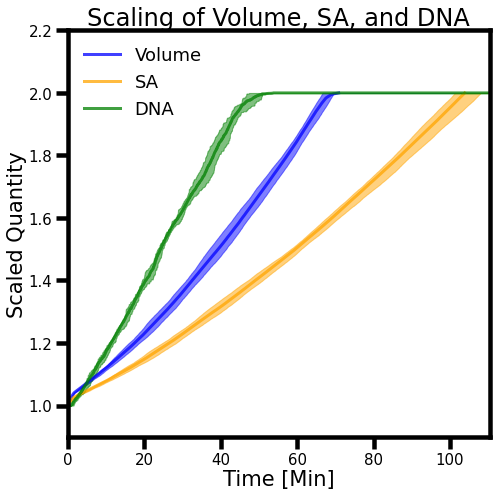

In [6]:
# DNA_content is the averaged copy number of chromosome
genes_locusNums = []

for geneType in TypetoLocusNums.keys():
    if geneType != 'gene':
        genes_locusNums.extend(TypetoLocusNums[geneType])

free_genes = ['G_{0}'.format(Gene) for Gene in genes_locusNums ]; free_genes_counts = w.get_species_traces(free_genes)
produced_genes = ['Produced_G_{0}'.format(Gene) for Gene in genes_locusNums ]; produced_genes_counts = w.get_species_traces(produced_genes)
DNA_content = 1 + np.mean(produced_genes_counts, axis=0)


fig_name = 'Duplication of DNA, Volume, and Surface  Area'
fig_size = [7,7]
pkl = w
ylabel = 'Scaled Quantity'
title = 'Scaling of Volume, SA, and DNA'
reps = healthy_list
colors = ['blue', 'orange', 'green']
legends = ['Volume', 'SA', 'DNA']

plot.plot_doubling(fig_dir, fig_name, fig_size,
               pkl, DNA_content,
               ylabel, title, reps, colors, legends, xlimit=[0,w.cell_cycle/60],
               title_set=True, fonts_sizes=[21, 21, 24, 18],
               extension='.png', tick_setting=[12, 4.5, 15, 'out'], line_widths = [3, 4.5],
               legend_pos='best')

### Chromosome Replication

#### Chromosome Replication Initiation

Hist ./plots_WCM/DNA Replication Initiation Time.png Replication Initiation: Min 0.82, Mean 1.11, Median 1.00, Max 1.53


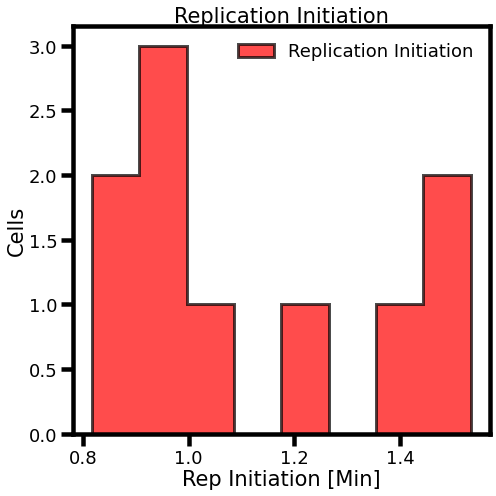

In [7]:
# Hist of initiation times

def first_0_to_1_transition(arr):
    """
    Find the first index where 0 transitions to 1 in a 1D NumPy array.
    
    Parameters:
        arr (numpy.ndarray): 1D binary NumPy array.

    Returns:
        int or None: Index of first 0 → 1 transition, or None if no transition is found.
    """
    transitions = np.where((arr[:-1] == 0) & (arr[1:] == 1))[0]
    return transitions[0] + 1 if transitions.size > 0 else None

init_check_count = w.get_specie_trace('RepInitCheck')

initiation_finish_time = []

for i_rep in range(init_check_count.shape[1]):
    init_time = first_0_to_1_transition(init_check_count[:,i_rep])
    initiation_finish_time.append(init_time/60)



fig_size=[7,7]
fig_name='DNA Replication Initiation Time'
data_list=[initiation_finish_time]
legends=['Replication Initiation']
colors = ['red']
xlabel='Rep Initiation [Min]'
ylabel='Cells'
title='Replication Initiation'
bins=8

plot.plot_hists(fig_dir, fig_name, fig_size,
            data_list, legends, colors, xlabel, ylabel, title, bins,
            mean_median=[False, False],
            title_set=True, fonts_sizes=[21, 21, 21, 18],
            extension='.png', range=None, 
            tick_setting=[12, 4.5, 18, 'out'], line_widths = [3, 4.5], legend_pos='best')

#### Replication of genes near the *Ori* and *Ter*

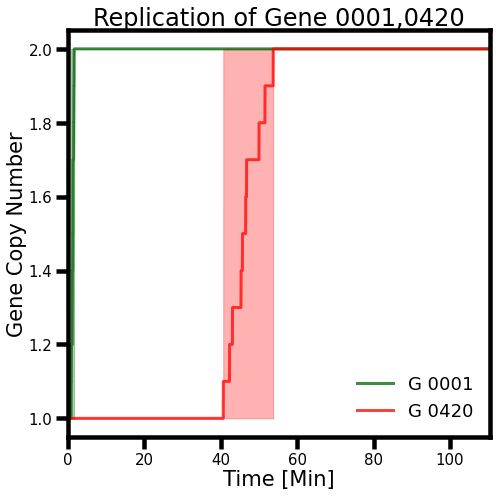

In [8]:
Ori_Ter_locusNums = ['0001', '0420']
data_list = [1+ w.get_specie_trace('Produced_G_'+_) for _ in Ori_Ter_locusNums]
xlabel = 'Time [Min]'
ylabel = 'Gene Copy Number'
title = f"Replication of Gene {','.join(_ for _ in Ori_Ter_locusNums)}"
percentile = [0,100]
colors = ['darkgreen', 'red']
fig_name='Replication of genes near Ori and Ter'
fig_size=[7,7]
time=w.t/60
legends=['G '+_ for _ in Ori_Ter_locusNums]

plot.plot_time_ranges(fig_dir, fig_name, fig_size,
               time, data_list, legends, colors, xlabel, ylabel, title,
               percentile, plot_avg=True, plot_range=True, xlimit=[0, w.cell_cycle/60],
               title_set=True, fonts_sizes=[21, 21, 24, 18],
               extension='.png', tick_setting=[12, 4.5, 15, 'out'], line_widths = [3, 4.5],
               legend_pos='best')

### Assembly and Activity of RNAP, Ribosome, and Degradosome

In [16]:
# RNAP
genes = []

for geneType in TypetoLocusNums.keys():
    if geneType != 'gene':
        genes.extend(TypetoLocusNums[geneType])

RNAP_core_count = w.get_specie_trace('RNAP_core')
free_RNAP_count = w.get_specie_trace('RNAP') + RNAP_core_count

# RNAP

RNAP_bound_ids = ['RNAP_G_' + locusNum for locusNum in genes]
RNAP_bound_counts = w.get_species_traces(RNAP_bound_ids)

active_RNAP_count = np.sum(RNAP_bound_counts, axis=0)
total_RNAP_count = free_RNAP_count + active_RNAP_count

ratio_RNAP = active_RNAP_count/total_RNAP_count

# Ribosome
count_produced_ribosome = w.get_specie_trace('Produced_Ribosome')

initial_ribosome_count = 500

count_ribosome = w.get_specie_trace('Ribosome')

active_ribosome = initial_ribosome_count + count_produced_ribosome - count_ribosome
total_ribosome = initial_ribosome_count + count_produced_ribosome

ratio_ribosome = active_ribosome / total_ribosome

# Degradosome

free_degra_count = w.get_specie_trace('Degradosome')

# Calculate active degradosome count
ptn_locusNums = TypetoLocusNums['protein']

degra_bound_ids = ['Degradosome_mRNA_' + locusNum for locusNum in ptn_locusNums]

degra_bound_counts = w.get_species_traces(degra_bound_ids)

active_degra_count = np.sum(degra_bound_counts, axis=0)

total_degra_count = free_degra_count + active_degra_count

ratio_degra = active_degra_count/total_degra_count

Hist ./plots_WCM/Hists of Scaled RNAP, Ribo and Degra.png RNAP: Min 1.34, Mean 1.79, Median 1.78, Max 2.08
Hist ./plots_WCM/Hists of Scaled RNAP, Ribo and Degra.png DEG: Min 1.52, Mean 1.73, Median 1.68, Max 2.05
Hist ./plots_WCM/Hists of Scaled RNAP, Ribo and Degra.png RIBO: Min 1.64, Mean 1.77, Median 1.78, Max 1.87


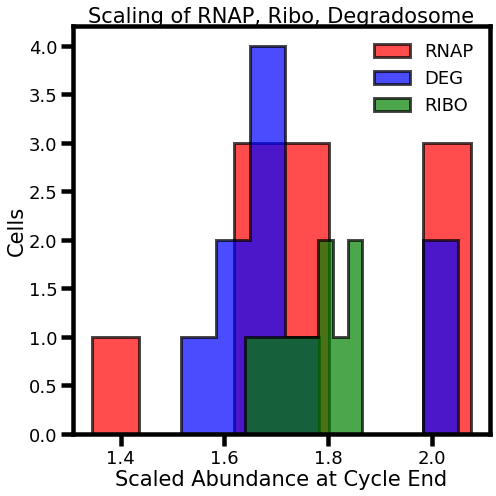

In [18]:
# Scaled RNAP, Ribo, Degra

fig_size=[7, 7]
fig_name='Hists of Scaled RNAP, Ribo and Degra'
data_list=[math.get_doubling_moments_value(surface_doubling_times,total_RNAP_count)/93,
           math.get_doubling_moments_value(surface_doubling_times,total_degra_count)/120,
           math.get_doubling_moments_value(surface_doubling_times,total_ribosome)/500]
legends = ['RNAP', 'DEG', 'RIBO']
colors = ['red', 'blue', 'green']
xlabel='Scaled Abundance at Cycle End'
ylabel='Cells'
title='Scaling of RNAP, Ribo, Degradosome'
bins=8
plot.plot_hists(fig_dir, fig_name, fig_size,
            data_list, legends, colors, xlabel, ylabel, title, bins,
            mean_median=[False, False],
            title_set=True, fonts_sizes=[21, 21, 21, 18],
            extension='.png', range=None, 
            tick_setting=[12, 4.5, 18, 'out'], line_widths = [3, 4.5], legend_pos='upper right')

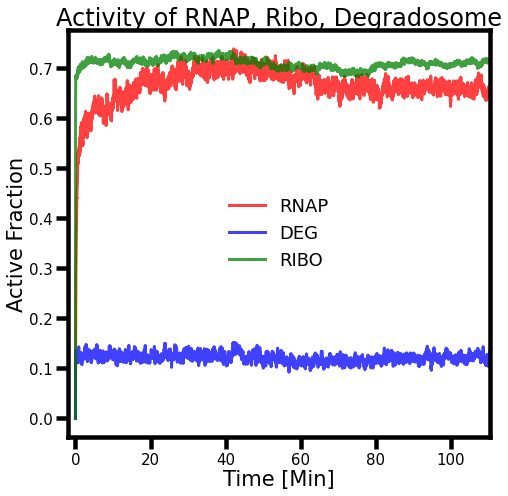

In [20]:
# Active RNAP Ribo Deg

fig_name = 'Time Active RNAP, Ribo, Deg'
fig_size = [7, 7]
data_list=[ratio_RNAP, ratio_degra, ratio_ribosome]
time = w.t/60
legends = ['RNAP', 'DEG', 'RIBO']
colors = ['red', 'blue', 'green']
xlabel='Time [Min]'
ylabel='Active Fraction'
title='Activity of RNAP, Ribo, Degradosome'
percentile = [0,100]

plot.plot_time_ranges(fig_dir, fig_name, fig_size,
               time, data_list, legends, colors, xlabel, ylabel, title,
               percentile, plot_avg=True, plot_range=False, xlimit=[-2, w.cell_cycle/60],
               title_set=True, fonts_sizes=[21, 21, 24, 18],
               extension='.png', tick_setting=[12, 4.5, 15, 'out'], line_widths = [3, 4.5],
               legend_pos='center')

### Protein Synthesis

#### Scaling of the entire proteome

Hist ./plots_WCM/Doubling of Proteome.png : Min 1.40, Mean 2.02, Median 2.02, Max 2.97


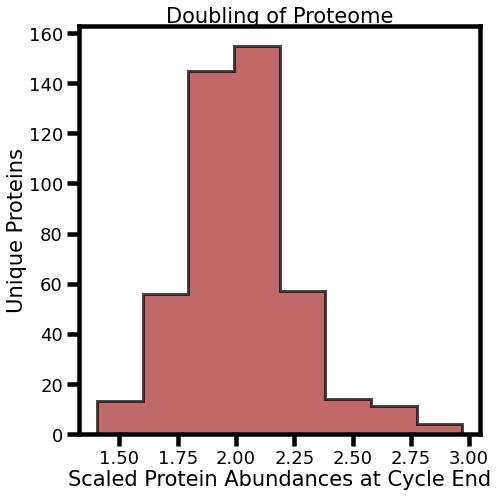

In [9]:
# Distribution of entire proteome

locusNums = ptn.getPtnlist(init_conc_path, 'entire')

ptns_ratio = ptn.getScaledPtnRatio(w, init_conc_path, locusNums, cplx_dict)

scaledPtn_SA_doubling = np.mean(math.get_doubling_moments_value(surface_doubling_times,ptns_ratio), axis=1)

fig_size=[7,7]
fig_name='Doubling of Proteome'
data_list=[scaledPtn_SA_doubling]
legends=['']
colors = ['brown']
xlabel='Scaled Protein Abundances at Cycle End'
ylabel='Unique Proteins'
title='Doubling of Proteome'
bins=8

plot.plot_hists(fig_dir, fig_name, fig_size,
            data_list, legends, colors, xlabel, ylabel, title, bins,
            mean_median=[False, False],
            title_set=True, fonts_sizes=[21, 21, 21, 18],
            extension='.png', range=None, 
            tick_setting=[12, 4.5, 18, 'out'], line_widths = [3, 4.5], legend_pos='upper left')

#### Stochastic Protein Synthesis at Single-Cell Level

As example, we choose protein **DnaA** that investigated in the previous tutorial. Change **`reps`** to see the patterns of protein synthesis in different cells.

You are encouraged to use the ones you like in **`initial_concentrations.xlsx`**.

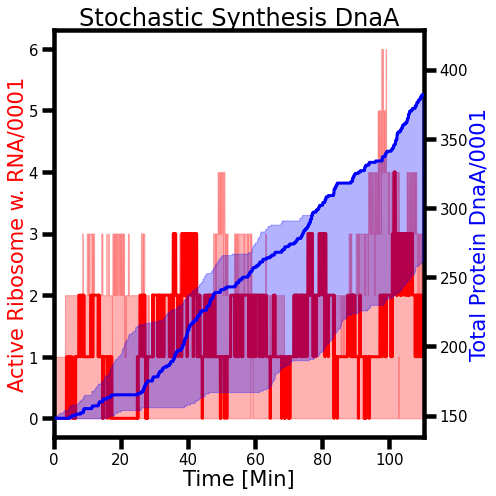

In [10]:
# Stochastic Protein Synthesis

ptn_name = 'DnaA'
ptn_locusNum = '0001'
RNC_prefix = 'RNC_'
produced_prefix = 'Produced_P_'
init_count = 148

produced_DnaA = w.get_specie_trace(produced_prefix+ptn_locusNum)
RNC_DnaA = w.get_specie_trace(RNC_prefix+ptn_locusNum) # Active ribosome translating mRNA encoding DnaA

reps = [4]
time = w.t/60
xlabel = 'Time [Min]'
title = f'Stochastic Synthesis {ptn_name}'
percentile = [0,100]
fig_size = [7,7]

for rep in reps:
    fig_name = f'Stochastic Synthesis of Protein {ptn_name} in Rep {rep}'

    left_data = [RNC_DnaA, RNC_DnaA[:,rep-1]]
    left_colors = ['red', 'red']
    left_ylabel = f'Active Ribosome w. RNA/{ptn_locusNum}'
    left_plots = ['range', 'single']
    left_ylabel_color = 'red'
    left_legends = len(left_data)*['']

    right_data = [produced_DnaA+init_count, produced_DnaA[:,rep-1]+init_count]
    right_colors = ['blue', 'blue']
    right_ylabel = f'Total Protein {ptn_name}/{ptn_locusNum}'
    right_plots = ['range', 'single']
    right_ylabel_color = 'blue'
    right_legends = len(left_data)*['']

    plot.plot_time_dualAxes(fig_dir, fig_name, fig_size,
                time, xlabel, title, percentile,
                left_data, left_legends, left_colors, left_ylabel, left_plots, left_ylabel_color,
                right_data, right_legends, right_colors, right_ylabel, right_plots, right_ylabel_color,
                xlimit=[0,w.cell_cycle/60], title_set=True, fonts_sizes=[21, 21, 24, 18],
                extension='.png', tick_setting=[12, 4.5, 15, 'out'], line_widths = [3,4.5], legend_pos='best')

#### Translation per mRNA

Hist ./plots_WCM/Translation per mRNA.png : Min 3.46, Mean 8.10, Median 7.98, Max 16.78


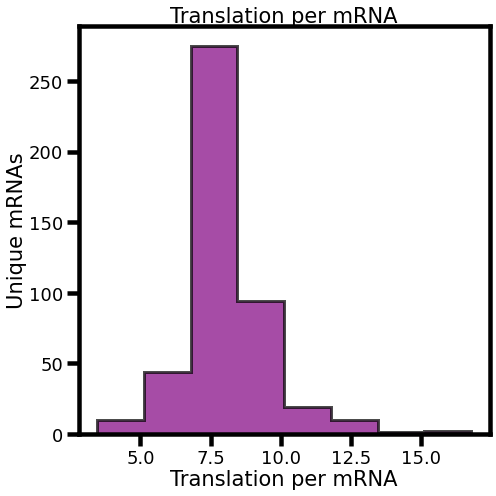

In [11]:
# Translation per mRNA
entire_locusNums = ptn.getPtnlist(init_conc_path, 'entire')
trans_per_mRNA, zero_mRNA_list = ptn.cal_translation_per_mRNA(w, entire_locusNums, healthy_list, surface_doubling_times, locations_ptns, lipo=False)

# Scaled RNAP, Ribo, Degra
fig_size=[7,7]
fig_name='Translation per mRNA'
data_list=[trans_per_mRNA]
legends=['']
colors = ['purple']
xlabel='Translation per mRNA'
ylabel='Unique mRNAs'
title='Translation per mRNA'
bins=8

plot.plot_hists(fig_dir, fig_name, fig_size,
            data_list, legends, colors, xlabel, ylabel, title, bins,
            mean_median=[False, False],
            title_set=True, fonts_sizes=[21, 21, 21, 18],
            extension='.png', range=None, 
            tick_setting=[12, 4.5, 18, 'out'], line_widths = [3, 4.5], legend_pos='upper left')

#### mRNA binding probability to ribosome or degradosome

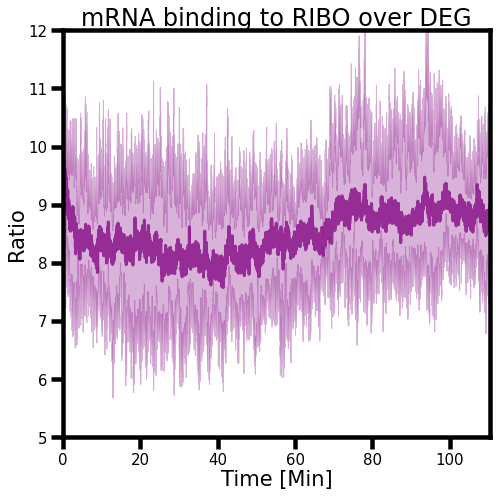

In [12]:
free_ribo_count = w.get_specie_trace('Ribosome') # 2D array
ribo_bind_rate = 8.9*1e4 # per molar per second

free_degra_count = w.get_specie_trace('Degradosome')
degra_bind_rate = 1.4*1e4 # per molar per second

ratio_probability = ribo_bind_rate*free_ribo_count/(degra_bind_rate*free_degra_count)

data_list = [ratio_probability]
xlabel = 'Time [Min]'
ylabel = 'Ratio'
title = f"mRNA binding to RIBO over DEG"
percentile = [0,100]
colors = ['purple']
fig_name=title
fig_size=[7,7]
time=w.t/60
legends=['']

plot.plot_time_ranges(fig_dir, fig_name, fig_size,
               time, data_list, legends, colors, xlabel, ylabel, title,
               percentile, plot_avg=True, plot_range=True, xlimit=[0, w.cell_cycle/60],
               title_set=True, fonts_sizes=[21, 21, 24, 18],
               extension='.png', tick_setting=[12, 4.5, 15, 'out'], line_widths = [3, 4.5],
               legend_pos='best', ylimit=[5,12])

### Slow down of gene expression, e.g. transcription elongation

In [13]:
# transcription rate drop

def transcriptionrate(w, rnasequence, ptn_count):
    from collections import defaultdict, OrderedDict

    # K0rep = 0.26e-3    # mM Binding of DNAP with gene
    rnaPolKd = 0.1 #mM

    rnaPolKcat = 20*ptn_count/180 # nt/s

    rnaPolKcat = min(rnaPolKcat,85)

    rnaPolKcat = max(10,rnaPolKcat)

    atp = w.get_conc_trace('M_atp_c')*1000 # 2D array
    ctp = w.get_conc_trace('M_ctp_c')*1000
    gtp = w.get_conc_trace('M_gtp_c')*1000
    utp = w.get_conc_trace('M_utp_c')*1000

    baseCount = defaultdict(int)
    for base in set(rnasequence):
        baseCount[base] = rnasequence.count(base)

    baseMap = OrderedDict({ "A":"M_atp_c", "U":"M_utp_c", "G":"M_gtp_c", "C":"M_ctp_c" })

    Mono1 = baseMap[ rnasequence[0] ]
    CMono1 = w.get_conc_trace(Mono1)*1000

    Mono2 = baseMap[ rnasequence[1] ]
    CMono2 = w.get_conc_trace(Mono2)*1000

    n_tot = sum(list(baseCount.values()))

    NMono_A = baseCount["A"]
    
    NMono_U = baseCount["U"]
    
    NMono_C = baseCount["C"]
    
    NMono_G = baseCount["G"]
    
    NMonoSum = NMono_A*rnaPolKd/atp + NMono_C*rnaPolKd/ctp + NMono_U*rnaPolKd/utp + NMono_G*rnaPolKd/gtp
    
    k_transcription = rnaPolKcat / ((rnaPolKd**2)/(CMono1*CMono2) + NMonoSum + n_tot - 1)

    return n_tot, k_transcription

gene_locusNum = '0001'
rnasequence = genomeDict['JCVISYN3A_0001']['RNAsequence']
n_tot, k_transcription = transcriptionrate(w, rnasequence, 148)


#### Full Span

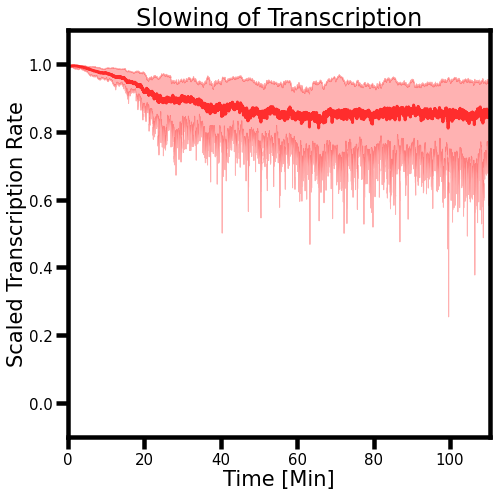

In [14]:
normalized_k = k_transcription/np.max(k_transcription) # Normalize
data_list = [normalized_k] 

xlabel = 'Time [Min]'
ylabel = 'Scaled Transcription Rate'
title = f"Slowing of Transcription"
percentile = [0,100]
colors = ['red']
fig_name='Slow Transcription Full Range'
fig_size=[7,7]
time=w.t/60
legends=['']

plot.plot_time_ranges(fig_dir, fig_name, fig_size,
               time, data_list, legends, colors, xlabel, ylabel, title,
               percentile, plot_avg=True, plot_range=True, xlimit=[0, w.cell_cycle/60],
               title_set=True, fonts_sizes=[21, 21, 24, 18],
               extension='.png', tick_setting=[12, 4.5, 15, 'out'], line_widths = [3, 4.5],
               legend_pos='lower right', ylimit=[-0.1,1.1])


#### Slow transcription in certain replicates

Change the **`reps`** to see the variation of different cells

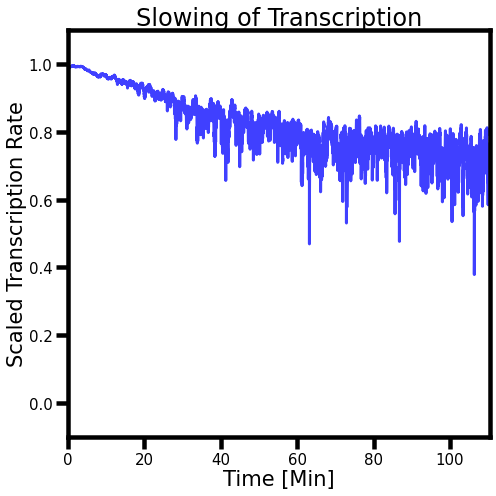

In [15]:
reps = [1]

xlabel = 'Time [Min]'
ylabel = 'Scaled Transcription Rate'
title = f"Slowing of Transcription"
percentile = [0,100]
colors = ['blue']
fig_size=[7,7]
time=w.t/60
legends=['']

for rep in reps:
    data_list = [normalized_k[:, rep-1:rep]]
    fig_name= f'Slow Transcription in Rep {rep}'

    plot.plot_time_ranges(fig_dir, fig_name, fig_size,
                time, data_list, legends, colors, xlabel, ylabel, title,
                percentile, plot_avg=True, plot_range=False, xlimit=[0, w.cell_cycle/60],
                title_set=True, fonts_sizes=[21, 21, 24, 18],
                extension='.png', tick_setting=[12, 4.5, 15, 'out'], line_widths = [3, 4.5],
                legend_pos='lower right', ylimit=[-0.1,1.1])